In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import seaborn as sns

In [21]:
df = pd.DataFrame(pd.read_csv("drug200.csv"))
x = df.drop("Drug",axis=1)
y = df["Drug"]
x = pd.get_dummies(x)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)
pre = model.predict(x_test)
acc = accuracy_score(y_test,pre)
acc

0.775

In [22]:
dic = {}
for i in range(1,10):
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(x_train,y_train)
    pre = model.predict(x_test)
    acc = accuracy_score(y_test,pre)
    dic[i] = acc
dic    

{1: 0.675,
 2: 0.675,
 3: 0.775,
 4: 0.725,
 5: 0.675,
 6: 0.65,
 7: 0.65,
 8: 0.675,
 9: 0.6}

In [23]:
best = max(dic,key=dic.get)
best

3

0.775
[[ 5  0  0  1  0]
 [ 0  2  0  1  0]
 [ 3  0  1  1  0]
 [ 1  2  0  8  0]
 [ 0  0  0  0 15]]
              precision    recall  f1-score   support

       drugA       0.56      0.83      0.67         6
       drugB       0.50      0.67      0.57         3
       drugC       1.00      0.20      0.33         5
       drugX       0.73      0.73      0.73        11
       drugY       1.00      1.00      1.00        15

    accuracy                           0.78        40
   macro avg       0.76      0.69      0.66        40
weighted avg       0.82      0.78      0.76        40



<Axes: >

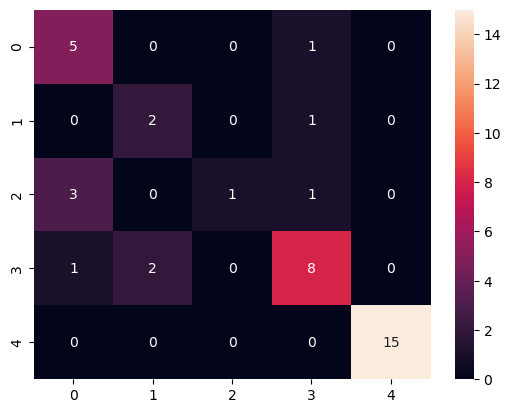

In [30]:
model = KNeighborsClassifier(n_neighbors=best)
model.fit(x_train,y_train)
pre = model.predict(x_test)
acc = accuracy_score(y_test,pre)
cols = x_train.columns
print(acc)
print(confusion_matrix(y_test,pre))
print(classification_report(y_test,pre))
sns.heatmap(confusion_matrix(y_test,pre),annot=True)

In [31]:
model.predict(pd.DataFrame([[47,10.114,0,1,0,1,0,1,0]], columns=cols))

array(['drugC'], dtype=object)

1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


<Axes: >

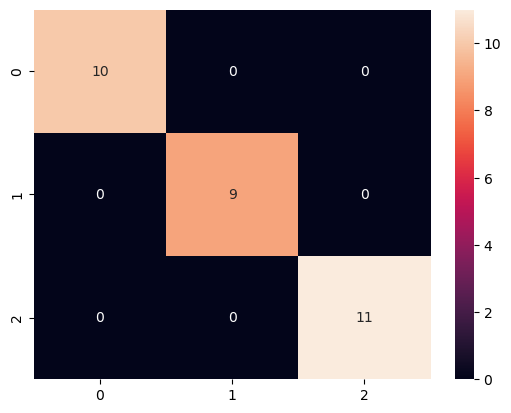

In [36]:
df = pd.DataFrame(pd.read_csv("Iris.csv"))
df.drop("Id",axis=1)
x = df.drop("Species",axis=1)
y = df["Species"]
x = pd.get_dummies(x)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)
pre = model.predict(x_test)
acc = accuracy_score(y_test,pre)
con = confusion_matrix(y_test,pre)
print(acc)
print(con)
sns.heatmap(con,annot=True)